In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_parquet("../data/processed/olist-processed-dataset.parquet")

In [3]:
data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,9350,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,9350,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,9350,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,31570,belo horizonte,SP,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,21.0,14840,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.0,None,None,2018-08-18,2018-08-22 19:07:58


Since there are not much data before 2017, we consider starting date as 2017.01.01  
&darr; &darr; &darr;

In [4]:
data_trimmed =  data[
                (data["order_status"] == "delivered") &
                (data["order_purchase_timestamp"] > "2017-01-01")
                ]

#### RFM Analysis

In [5]:
rfm_df = data_trimmed.groupby("customer_unique_id").agg(
    frequency=("order_id", "nunique"),
    monetary=("price", "sum"),
    last_purchase=("order_purchase_timestamp", "max"))

In [6]:
rfm_df[rfm_df["frequency"] > 1].sort_values(by=["frequency"], ascending=False)

,frequency,monetary,last_purchase
customer_unique_id,,,
8d50f5eadf50201ccdcedfb9e2ac8455,15,714.63,2018-08-20 19:14:26
3e43e6105506432c953e165fb2acf44c,9,1000.85,2018-02-27 18:36:39
1b6c7548a2a1f9037c1fd3ddfed95f33,7,855.21,2018-02-14 13:22:12
ca77025e7201e3b30c44b472ff346268,7,806.61,2018-06-01 11:38:29
6469f99c1f9dfae7733b25662e7f1782,7,664.20,2018-06-28 00:43:34
...,...,...,...
0241fa2e9adf0576cb0f845377d05c03,2,132.31,2018-07-24 21:24:13
027803eb28cc01fbdf5da72b109fabee,2,64.99,2017-10-17 11:28:18
029b457bd01199c39136f89e0eddcd3a,2,278.00,2018-01-04 19:21:49


In [7]:
rfm_df[rfm_df["frequency"] > 1].sort_values(by=["frequency"], ascending=False).shape[0] * 100 / rfm_df.shape[0]

2.995574841037979

&uarr; &uarr; &uarr;  
This result shows that 3% of the customers made the 2nd purchase

In [8]:
last_day = (rfm_df["last_purchase"].max() + pd.Timedelta(days=1))
last_day

Timestamp('2018-08-30 15:00:37')

In [9]:
rfm_df["days_since_last_purchase"] = (last_day - rfm_df["last_purchase"])

In [10]:
rfm_df["days_since_last_purchase"] = rfm_df["days_since_last_purchase"].dt.total_seconds() / 86400
rfm_df["days_since_last_purchase"] = rfm_df["days_since_last_purchase"].round(2)

In [11]:
rfm_df.head()

,frequency,monetary,last_purchase,days_since_last_purchase
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,2018-05-10 10:56:27,112.17
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,2018-05-07 11:11:27,115.16
0000f46a3911fa3c0805444483337064,1,69.00,2017-03-10 21:05:03,537.75
0000f6ccb0745a6a4b88665a16c9f078,1,25.99,2017-10-12 20:29:41,321.77
0004aac84e0df4da2b147fca70cf8255,1,180.00,2017-11-14 19:45:42,288.80


In [12]:
rfm_df["days_since_last_purchase"].mean()

np.float64(237.22855409004984)

In [13]:
q_monetary = rfm_df["monetary"].quantile(0.99)
big_spenders = rfm_df[rfm_df["monetary"] >= q_monetary]
rfm_df_trim = rfm_df[
                    (rfm_df["monetary"] < q_monetary) &
                    (rfm_df["frequency"] < 15)]

&uarr; &uarr; &uarr;  
There is only one big frequency outlier (with value of 16)

In [14]:
big_spenders.shape

(932, 4)

&uarr; &uarr; &uarr;  
These are outlier customers whom spend high amounts in small frequency. We seperate them for the sake of keeping the main data more analysible. Optionally, we might look into these later

In [15]:
rfm_df_trim.describe()

,frequency,monetary,last_purchase,days_since_last_purchase
count,92171.000000,92171.000000,92171,92171.000000
mean,1.032722,130.996064,2018-01-05 11:20:26.770035968,237.152890
min,1.000000,0.850000,2017-01-05 11:56:06,1.000000
25%,1.000000,48.000000,2017-09-19 10:34:26.500000,114.790000
50%,1.000000,89.900000,2018-01-23 17:07:10,218.910000
75%,1.000000,156.000000,2018-05-07 20:00:57.500000,345.185000
max,9.000000,1099.000000,2018-08-29 15:00:37,602.130000
std,0.201796,141.314302,NaN,150.858067


##### Segmentation

In [16]:
rfm_df_trim["R"] = pd.qcut(rfm_df_trim["days_since_last_purchase"],
                          q=5,
                          labels=[5,4,3,2,1]).astype(int)


rfm_df_trim["F"] = rfm_df_trim["frequency"].apply(lambda x: 5 if x > 1 else 1)


rfm_df_trim["M"] = pd.qcut(rfm_df_trim["monetary"],
                          q=5,
                          labels=[1,2,3,4,5]).astype(int)

&uarr; &uarr; &uarr;  
Since there are not much customers who make repeated purchases in this dataset, we make a two segmented frequency flag

In [17]:
rfm_df_trim["RFM_score"] = (rfm_df_trim["R"].astype(str) + 
                           rfm_df_trim["F"].astype(str) + 
                            rfm_df_trim["M"].astype(str))

In [18]:
def segmentation(row):
    if row["RFM_score"] == "555":
        return "Champion"
    elif row["R"] >= 4 and row["M"] >= 4 and row["F"] == 1:
        return "Potential"
    elif row["F"] == 5 and row["M"] >=4 and row["R"] < 4:
        return "At Risk High Value"
    elif row["F"] == 5 and row ["R"] < 4 and row["M"] <= 3:
        return "At Risk"
    elif row["F"] == 5 and row["R"] >= 4:
        return "Loyal"
    elif row["R"] >= 4:
        return "Recent"
    elif row["R"] < 3 and row["F"] == 1:
        return "Lost"
    else:
        return "Standard"


rfm_df_trim["segment"] = rfm_df_trim.apply(segmentation, axis=1)

In [19]:
segment_size = rfm_df_trim.groupby("segment")[["frequency"]].count()
segment_size = segment_size.rename(columns={"frequency" : "customer_count"})
segment_size["percentage"] = segment_size["customer_count"] * 100 / segment_size["customer_count"].sum()
segment_size["percentage"] = segment_size["percentage"].round(2)
segment_size.sort_values(by="percentage", ascending=False)
segment_size = segment_size.reset_index().sort_values(by="percentage")
segment_size

,segment,customer_count,percentage
2,Champion,325,0.35
0,At Risk,386,0.42
4,Loyal,842,0.91
1,At Risk High Value,1175,1.27
5,Potential,14268,15.48
7,Standard,17848,19.36
6,Recent,21434,23.25
3,Lost,35893,38.94


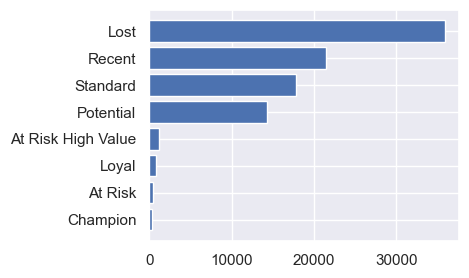

In [20]:
plt.figure(figsize=[4,3])
plt.barh(y=segment_size["segment"], width=segment_size["customer_count"])
plt.show()

In [21]:
segment_avgs = rfm_df_trim.groupby("segment")[["monetary","days_since_last_purchase"]].mean()
segment_avgs = segment_avgs.reset_index().sort_values(by="monetary")
segment_avgs

,segment,monetary,days_since_last_purchase
6,Recent,56.007821,89.948208
0,At Risk,75.192280,333.942021
7,Standard,124.814408,219.765334
3,Lost,128.222080,392.674943
4,Loyal,206.344667,105.668135
5,Potential,237.532631,91.976900
1,At Risk High Value,283.736511,313.891081
2,Champion,364.096800,46.132585


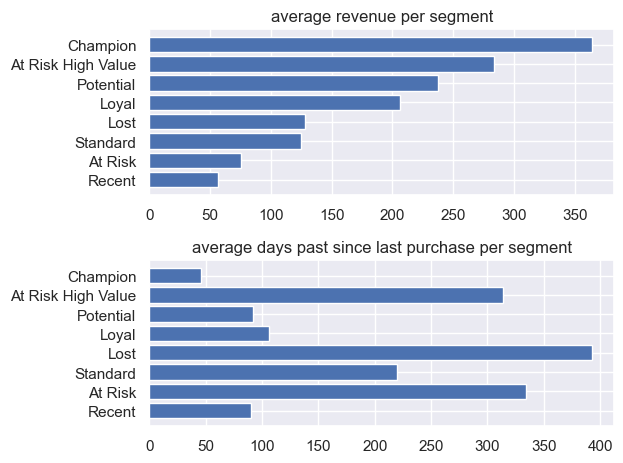

In [22]:
f, (ax1, ax2) = plt.subplots(2, 1, sharey=True)
ax1.barh(segment_avgs["segment"], segment_avgs["monetary"])
ax1.set_title("average revenue per segment")
ax2.barh(segment_avgs["segment"], segment_avgs["days_since_last_purchase"])
ax2.set_title("average days past since last purchase per segment")
plt.tight_layout()
plt.show()

In [57]:
segment_mon_sums = rfm_df_trim.groupby("segment").agg(total_revenue=("monetary","sum"),
                                                     customer_count=("monetary","count")).sort_values(by="total_revenue",ascending=False)

segment_mon_sums["revenue_percentage"] = segment_mon_sums["total_revenue"] * 100 / segment_mon_sums["total_revenue"].sum()
segment_mon_sums["revenue_percentage"] = segment_mon_sums["revenue_percentage"].round(2)
segment_mon_sums["customer_percentage"] = segment_mon_sums["customer_count"] * 100 / segment_mon_sums["customer_count"].sum()
segment_mon_sums["customer_percentage"] = segment_mon_sums["customer_percentage"].round(2)
segment_mon_sums["revenue_index"] = (segment_mon_sums["revenue_percentage"] / segment_mon_sums["customer_percentage"])
segment_mon_sums = segment_mon_sums.reset_index()
segment_mon_sums.sort_values("revenue_index", ascending=False)

,segment,total_revenue,customer_count,revenue_percentage,customer_percentage,revenue_index
6,Champion,118331.46,325,0.98,0.35,2.800000
4,At Risk High Value,333390.40,1175,2.76,1.27,2.173228
1,Potential,3389115.58,14268,28.07,15.48,1.813307
5,Loyal,173742.21,842,1.44,0.91,1.582418
0,Lost,4602275.11,35893,38.12,38.94,0.978942
2,Standard,2227687.56,17848,18.45,19.36,0.952996
7,At Risk,29024.22,386,0.24,0.42,0.571429
3,Recent,1200471.64,21434,9.94,23.25,0.427527


&uarr; &uarr; &uarr;  
The "revenue index" column shows, how much revenue a segment brings compared to their customer count percentage

##### Pareto Analysis

In [68]:
pareto_df = rfm_df_trim.sort_values("monetary", ascending=False).reset_index(drop=True)

In [73]:
pareto_df["revenue_cum_pct"] = pareto_df["monetary"].cumsum() / pareto_df["monetary"].sum()*100
pareto_df["customer_cum_pct"] = ( pareto_df.index + 1 ) / len(pareto_df) * 100

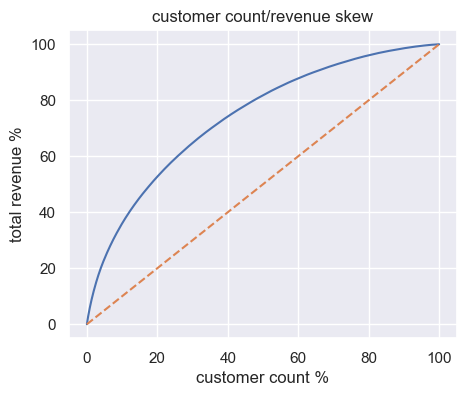

In [80]:
plt.figure(figsize=[5,4])
plt.plot(pareto_df["customer_cum_pct"], pareto_df["revenue_cum_pct"])
plt.plot([0, 100], [0, 100], linestyle="--")
plt.xlabel("customer count %")
plt.ylabel("total revenue %")
plt.title("customer count/revenue skew")
plt.show()

In [81]:
rfm_df_trim.to_parquet("../data/processed/rfm_segments.parquet", index=False)